# Data Exploration and Analysis

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)
spotify_wb_data = pd.read_csv("../../data/processed/spotify-wb-cleaned.csv")

## Exploration

### Question 1

My first specific question is:
- Does a country's economic development shape how often foreign vs. domestic artists nominate charts?

My thought process here is that countries with higher GDP per capita may have more globalized music tastes (and thus more foreign hits) while countries with lower GDP or higher inequality might have stronger domestic cultural dominance.

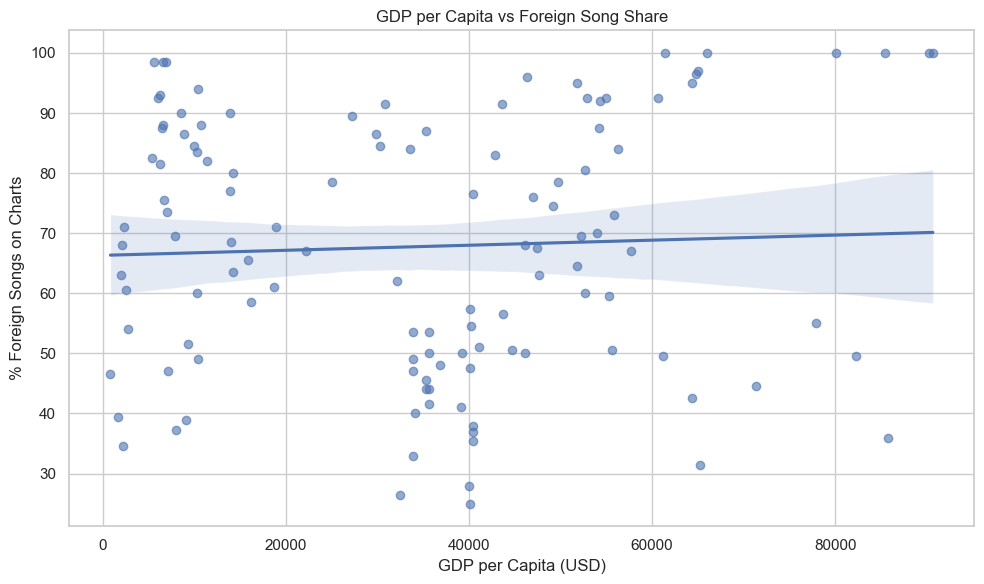

In [39]:
# computing foreign artists per country-year
country_year = (
    spotify_wb_data.groupby(['country_name', 'year'])
      .agg(
          foreign_share=('foreign', 'mean'),
          domestic_share=('domestic', 'mean'),
          avg_streams=('streams', 'mean'),
          avg_peak=('peak_rank', 'mean'),
          gdp_per_capita=('NY.GDP.PCAP.CD', 'mean')
      )
      .reset_index()
)

country_year['foreign_share'] *= 100
country_year['domestic_share'] *= 100

# scatterplot - gdp per capita vs. foreign
plt.figure(figsize=(10, 6))
sns.regplot(
    data=country_year,
    x='gdp_per_capita',
    y='foreign_share',
    scatter_kws={'alpha': 0.6}
)
plt.title("GDP per Capita vs Foreign Song Share")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("% Foreign Songs on Charts")
plt.tight_layout()
plt.show()

### Question 2

My second specific question is:
- Are foreign artists more likely to achieve higher peak rank or longer chart survival?

The idea here is to compare longevity performance for domestic vs. foreign artists.

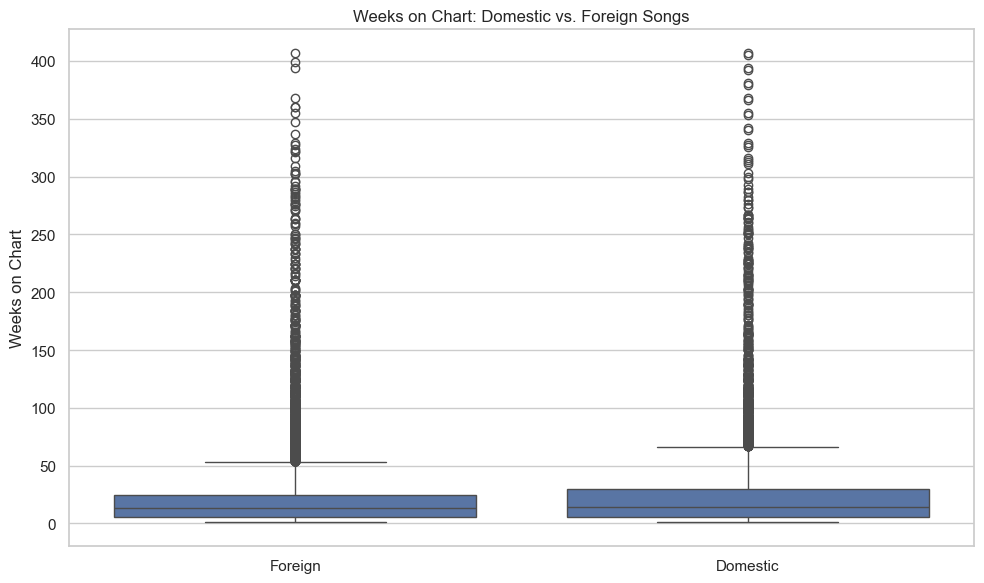

In [40]:
spotify_wb_data['type'] = spotify_wb_data['foreign'].map({1: "Foreign", 0: "Domestic"})

# boxplots compating foreign vs. domestic
plt.figure(figsize=(10, 6))
sns.boxplot(data=spotify_wb_data, x='type', y='weeks_on_chart')
plt.title("Weeks on Chart: Domestic vs. Foreign Songs")
plt.xlabel("")
plt.ylabel("Weeks on Chart")
plt.tight_layout()
plt.show()

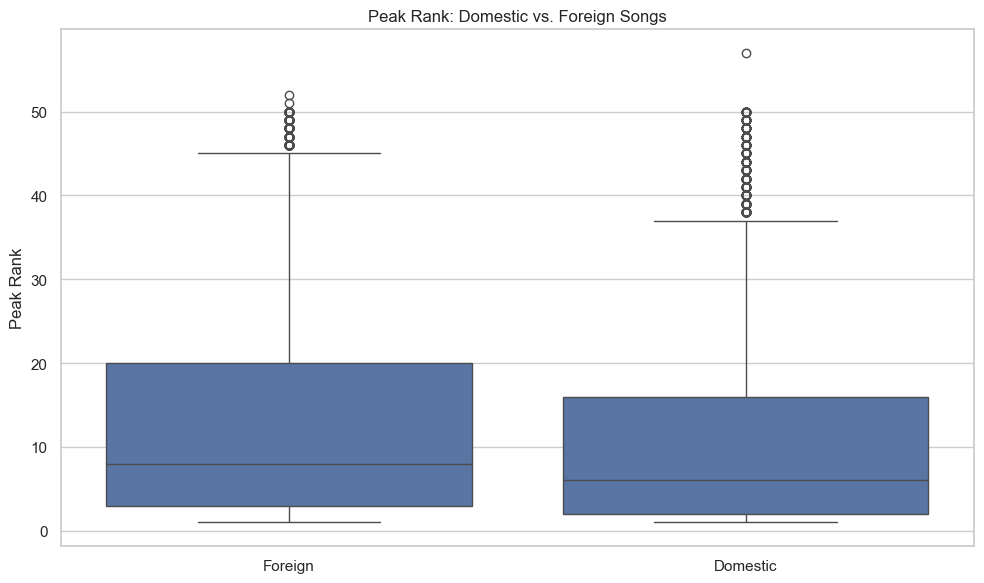

In [42]:
# peak rank (smaller number is better)
plt.figure(figsize=(10, 6))
sns.boxplot(data=spotify_wb_data, x='type', y='peak_rank')
plt.title("Peak Rank: Domestic vs. Foreign Songs")
plt.xlabel("")
plt.ylabel("Peak Rank")
plt.tight_layout()
plt.show()

### Question 3

My third specific question is:
- Do macroeconomic shocks (like inflation spikes) shift cultural consumption to domestic artists?

This is just me thinking about how economic factors can play into music consumption, since the music industry itself is, of course, affected by domestic economic conditions. (Or even political, but that is unfortunately outside the scope of my dataset).

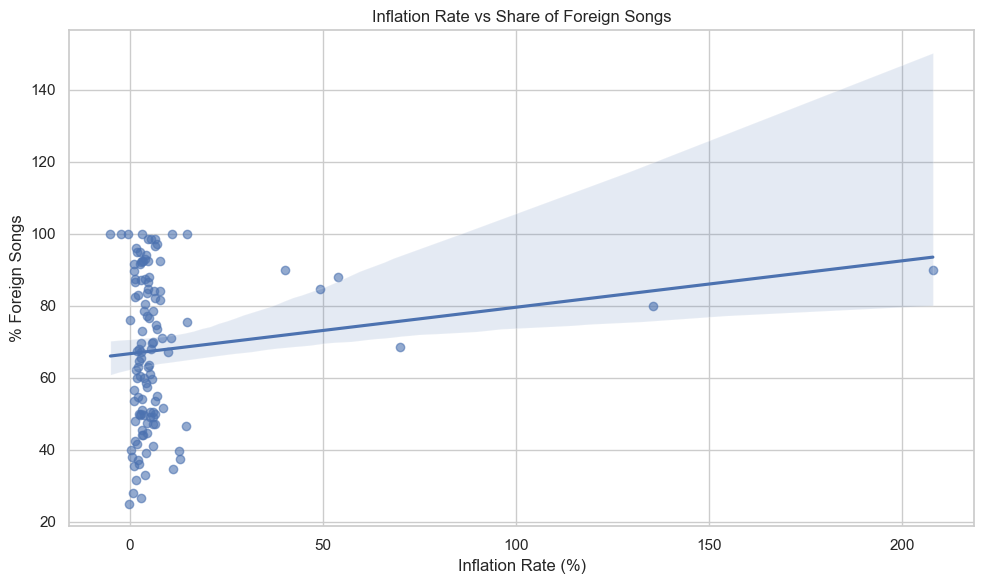

In [44]:
# calculating inflation

inflation = (
    spotify_wb_data.groupby(['country_name', 'year'])
      .agg(
          foreign_share=('foreign', 'mean'),
          inflation_rate=('NY.GDP.DEFL.KD.ZG', 'mean')
      )
      .reset_index()
)

inflation['foreign_share'] *= 100

# scatterplot with regression
plt.figure(figsize=(10, 6))
sns.regplot(
    data=inflation,
    x='inflation_rate',
    y='foreign_share',
    scatter_kws={'alpha': 0.6}
)
plt.title("Inflation Rate vs Share of Foreign Songs")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("% Foreign Songs")
plt.tight_layout()
plt.show()


C:\Users\HVNLY\AppData\Local\Temp\ipykernel_7164\915120503.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


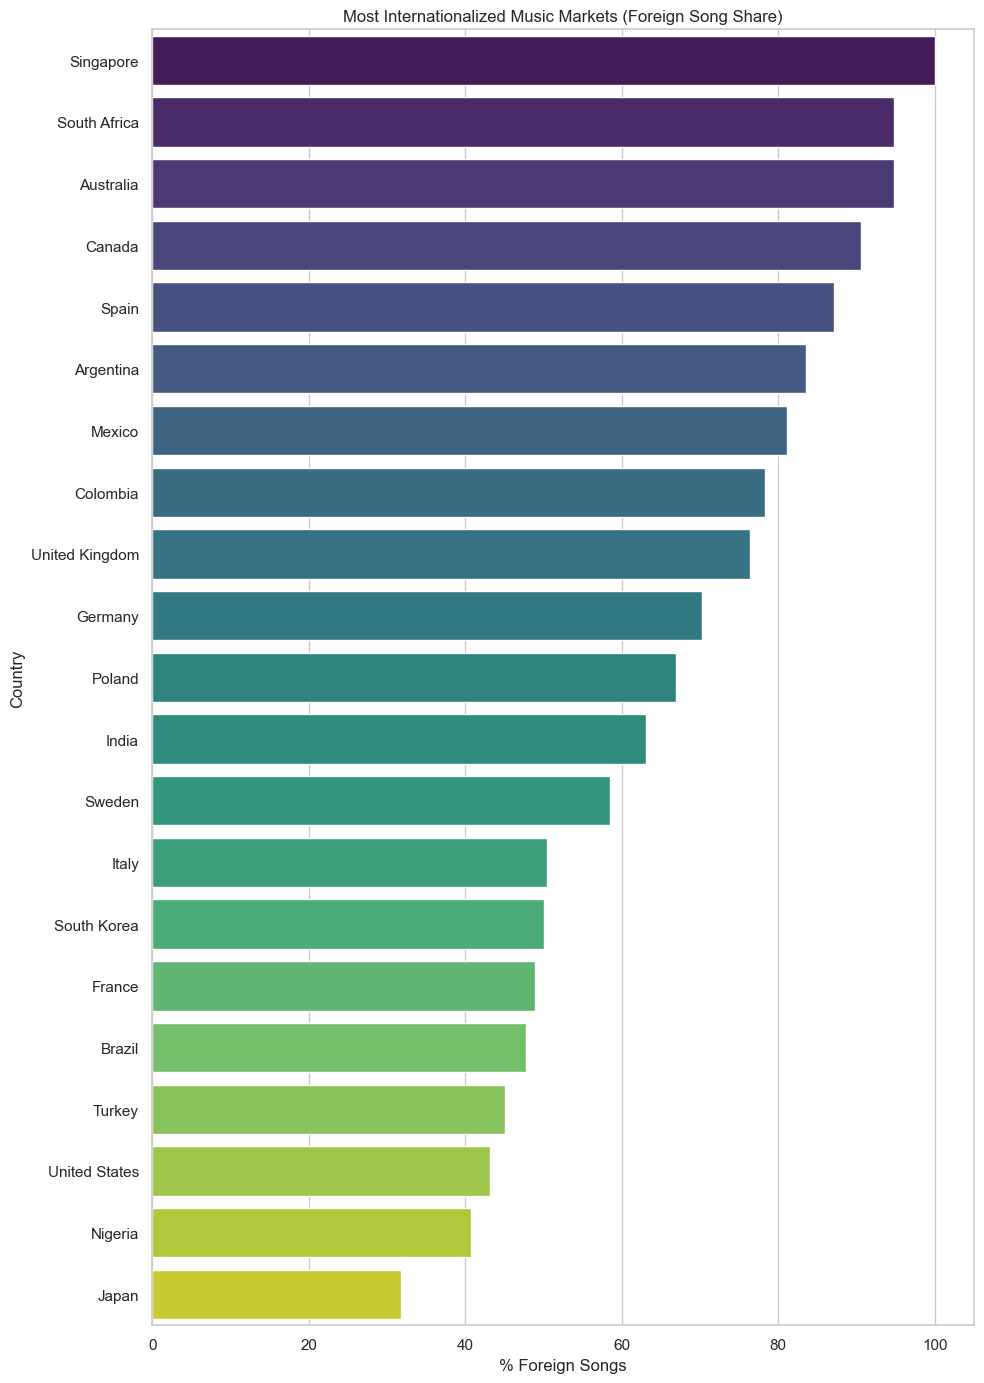

In [ ]:
# % foreign artists in tracks per country
country_global = (
    spotify_wb_data.groupby('country_name')
      .agg(foreign_share=('foreign', 'mean'))
      .reset_index()
)

country_global['foreign_share'] *= 100
country_global = country_global.sort_values('foreign_share', ascending=False)

plt.figure(figsize=(10, 14))
sns.barplot(
    data=country_global,
    y='country_name',
    x='foreign_share',
    palette='viridis'
)
plt.title("Most Internationalized Music Markets (Foreign Song Share)")
plt.xlabel("% Foreign Songs")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


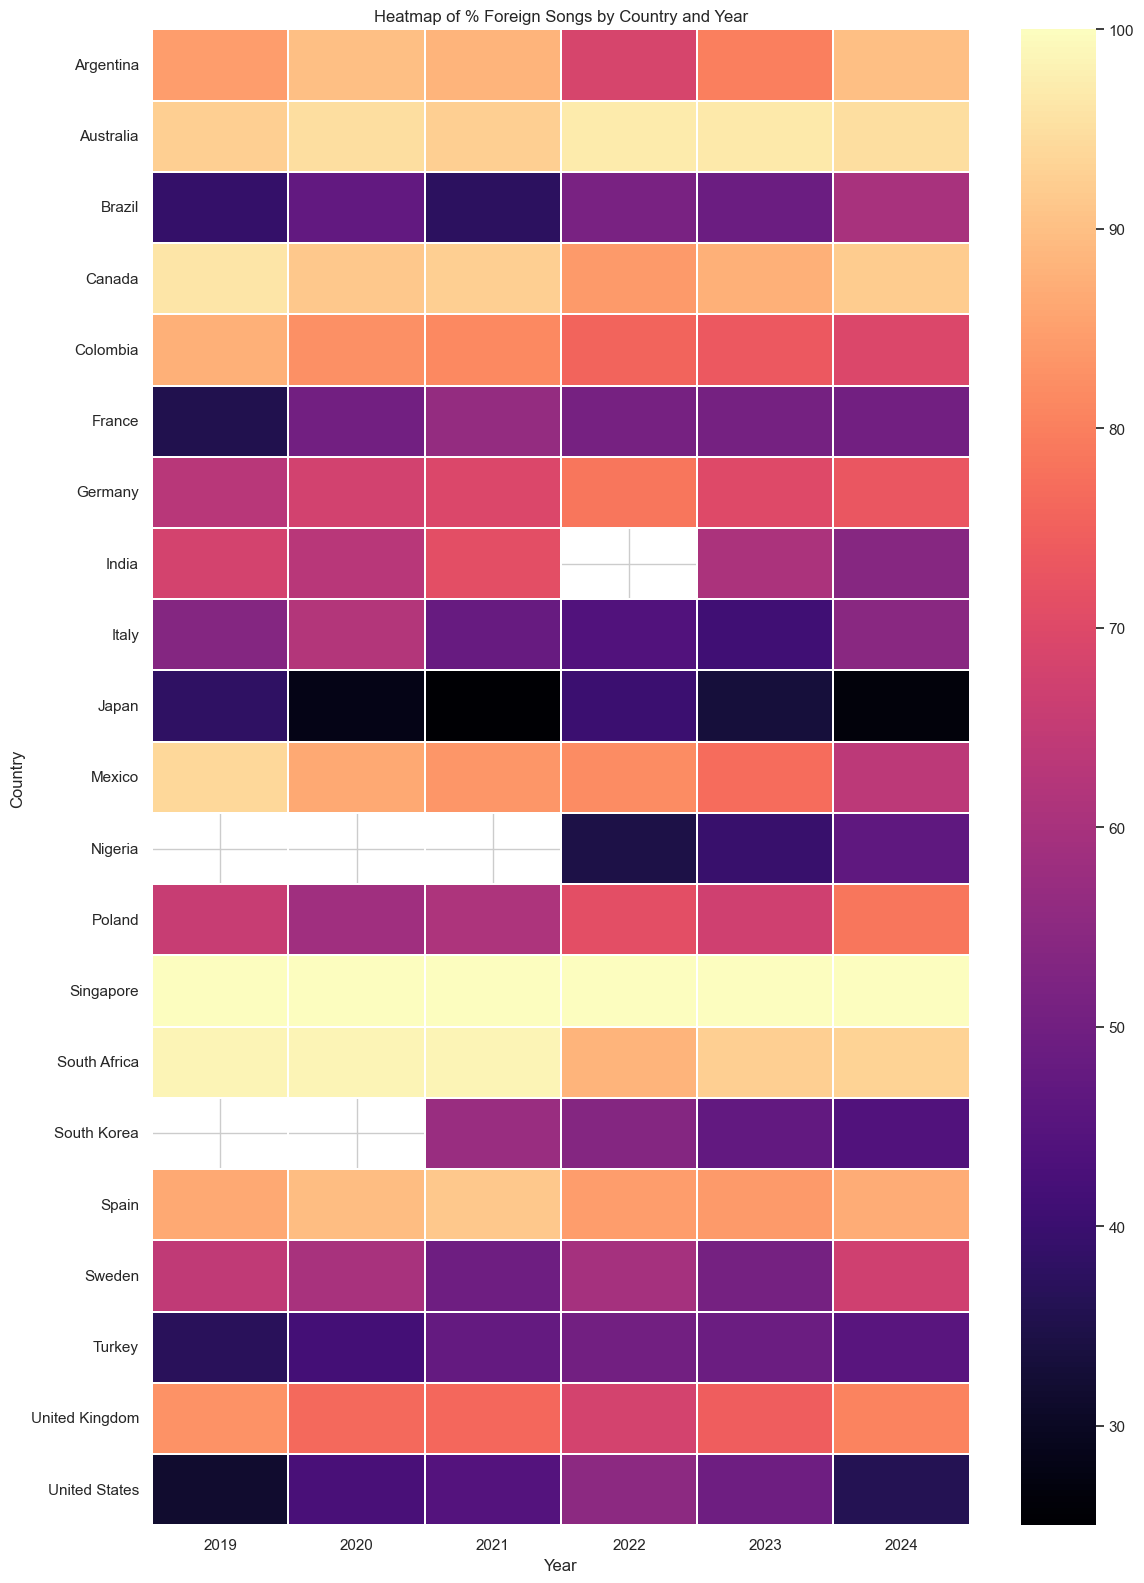

In [46]:
heatmap_data = country_year.pivot_table(
    index='country_name',
    columns='year',
    values='foreign_share'
)

plt.figure(figsize=(12, 16))
sns.heatmap(
    heatmap_data,
    cmap='magma',
    annot=False,
    linewidths=0.3
)

plt.title("Heatmap of % Foreign Songs by Country and Year")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

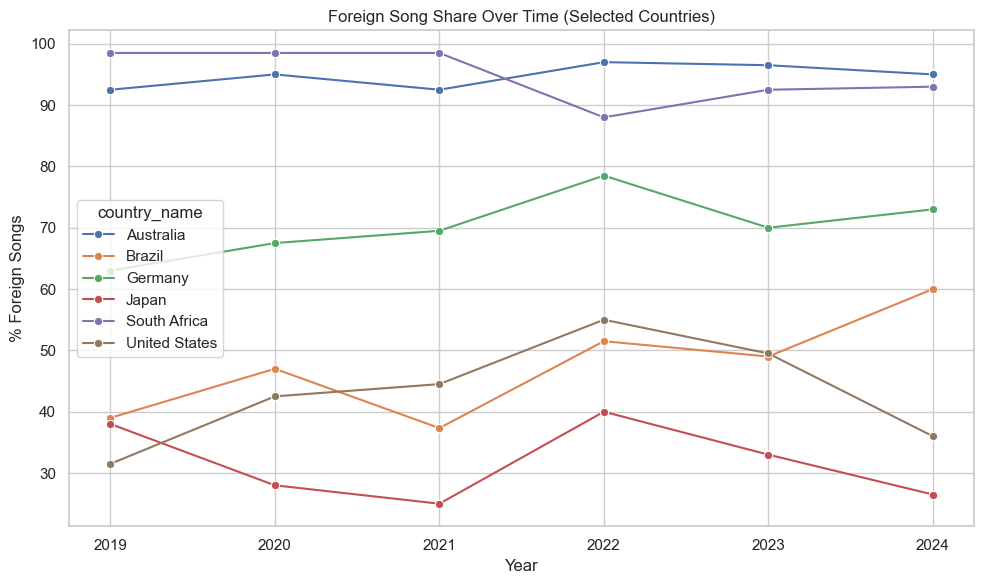

In [49]:
countries_to_plot = ['United States', 'Brazil', 'Germany', 'Japan', 'South Africa', 'Australia']

subset = country_year[country_year['country_name'].isin(countries_to_plot)]

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=subset,
    x='year',
    y='foreign_share',
    hue='country_name',
    marker="o"
)
plt.title("Foreign Song Share Over Time (Selected Countries)")
plt.xlabel("Year")
plt.ylabel("% Foreign Songs")
plt.tight_layout()
plt.show()


# V2

In [52]:
# Load the cleaned dataset
file_path = '../../data/processed/spotify-wb-cleaned.csv'
df = pd.read_csv(file_path)

# overview
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nBasic stats:")
display(df.describe())

Dataset shape: (23800, 36)

Columns: ['rank', 'artist_names', 'track_name', 'source', 'peak_rank', 'previous_rank', 'weeks_on_chart', 'streams', 'country_code', 'country_name', 'quarter', 'year', 'domestic', 'foreign', 'country', 'country_code_wb', 'BM.KLT.DINV.WD.GD.ZS', 'BX.KLT.DINV.WD.GD.ZS', 'GC.TAX.INTT.RV.ZS', 'IT.CEL.SETS.P2', 'IT.NET.BBND.P2', 'IT.NET.SECR', 'IT.NET.USER.ZS', 'NE.EXP.GNFS.ZS', 'NE.IMP.GNFS.ZS', 'NY.GDP.DEFL.KD.ZG', 'NY.GDP.DEFL.KD.ZG.AD', 'NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD', 'SI.POV.GINI', 'SP.POP.GROW', 'SP.POP.TOTL', 'SP.RUR.TOTL.ZG', 'SP.RUR.TOTL.ZS', 'SP.URB.GROW', 'SP.URB.TOTL.IN.ZS']

Basic stats:


,rank,peak_rank,previous_rank,weeks_on_chart,streams,year,domestic,foreign,BM.KLT.DINV.WD.GD.ZS,BX.KLT.DINV.WD.GD.ZS,...,NY.GDP.DEFL.KD.ZG.AD,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,SI.POV.GINI,SP.POP.GROW,SP.POP.TOTL,SP.RUR.TOTL.ZG,SP.RUR.TOTL.ZS,SP.URB.GROW,SP.URB.TOTL.IN.ZS
count,23800.000000,23800.000000,23800.000000,23800.000000,2.380000e+04,23800.000000,23800.000000,23800.000000,23800.000000,23800.000000,...,23800.000000,23800.000000,23800.000000,23800.000000,23800.000000,2.380000e+04,23800.000000,23800.000000,23800.000000,23800.000000
mean,25.572983,12.135714,24.682857,22.970798,1.317848e+06,2021.573529,0.484496,0.679328,2.620456,3.728403,...,8.798555,1.702721,34844.222735,36.098319,0.670630,1.371665e+08,-0.604036,20.295952,0.996628,79.704048
std,14.488238,12.211502,19.249071,33.316320,1.561007e+06,1.709148,0.499770,0.466745,3.231369,5.880188,...,23.816124,4.239359,23123.342082,6.755566,0.979356,2.727133e+08,0.775669,13.044197,1.095041,13.044197
min,1.000000,1.000000,-1.000000,1.000000,1.266300e+04,2019.000000,0.000000,0.000000,-0.753954,-0.893870,...,-5.018643,-10.940071,806.945695,28.500000,-4.170336,5.453566e+06,-1.822453,0.000000,-4.170336,34.472000
25%,13.000000,2.000000,10.000000,6.000000,4.148875e+05,2020.000000,0.000000,0.000000,0.619743,1.364600,...,2.312958,0.259936,10377.589279,32.300000,0.225520,4.128860e+07,-1.155888,13.231500,0.429610,77.765000
50%,26.000000,7.000000,23.000000,13.000000,8.602265e+05,2022.000000,0.000000,1.000000,1.322139,2.294784,...,4.068198,1.821407,35653.904210,33.800000,0.673994,5.972908e+07,-0.643978,18.138000,0.921469,81.862000
75%,38.000000,18.250000,36.000000,26.000000,1.543300e+06,2023.000000,1.000000,1.000000,3.863068,3.260932,...,6.235280,4.108000,52265.654162,36.325000,1.069840,1.245166e+08,-0.271283,22.235000,1.446826,86.768500
max,61.000000,57.000000,196.000000,407.000000,2.468637e+07,2024.000000,1.000000,1.000000,18.400586,33.304581,...,207.921861,10.801198,90674.066633,55.100000,4.858316,1.450936e+09,2.309520,65.528000,4.858316,100.000000


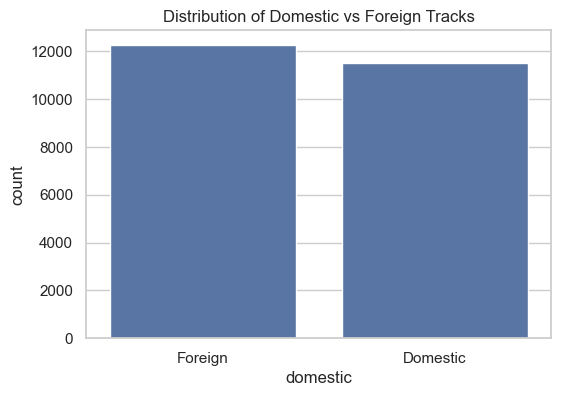

In [53]:
# domestic vs foreign artists
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='domestic')
plt.title("Distribution of Domestic vs Foreign Tracks")
plt.xticks([0,1], ["Foreign", "Domestic"])
plt.show()

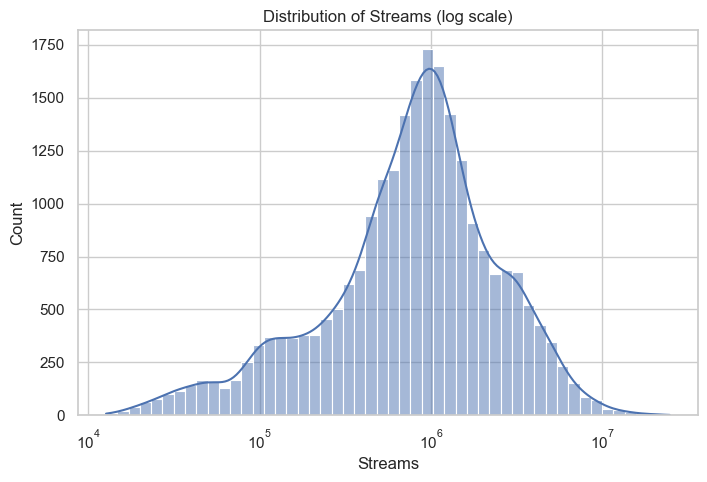

In [54]:
# streams analysis
plt.figure(figsize=(8,5))
sns.histplot(df['streams'], bins=50, log_scale=True, kde=True)
plt.title("Distribution of Streams (log scale)")
plt.xlabel("Streams")
plt.show()

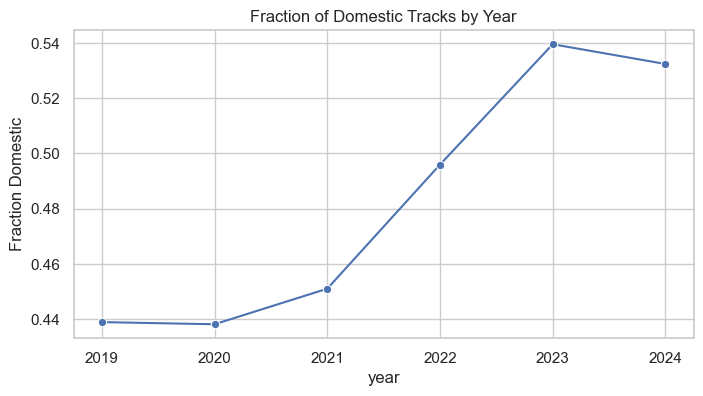

In [55]:
# percent by year
domestic_year = df.groupby('year')['domestic'].mean().reset_index()
plt.figure(figsize=(8,4))
sns.lineplot(data=domestic_year, x='year', y='domestic', marker='o')
plt.title("Fraction of Domestic Tracks by Year")
plt.ylabel("Fraction Domestic")
plt.show()

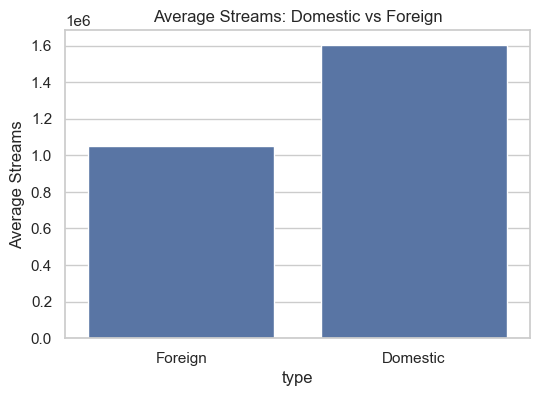

In [56]:
# average streams by domestic/foreign
avg_streams = df.groupby('domestic')['streams'].mean().reset_index()
avg_streams['type'] = avg_streams['domestic'].map({0:'Foreign', 1:'Domestic'})
plt.figure(figsize=(6,4))
sns.barplot(data=avg_streams, x='type', y='streams')
plt.title("Average Streams: Domestic vs Foreign")
plt.ylabel("Average Streams")
plt.show()

In [57]:
# clustering / segment exploration
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='cluster', hue='domestic')
plt.title("Cluster distribution by Domestic vs Foreign tracks")
plt.xlabel("Economic Cluster")
plt.ylabel("Number of Tracks")
plt.show()

ValueError: Could not interpret value `cluster` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

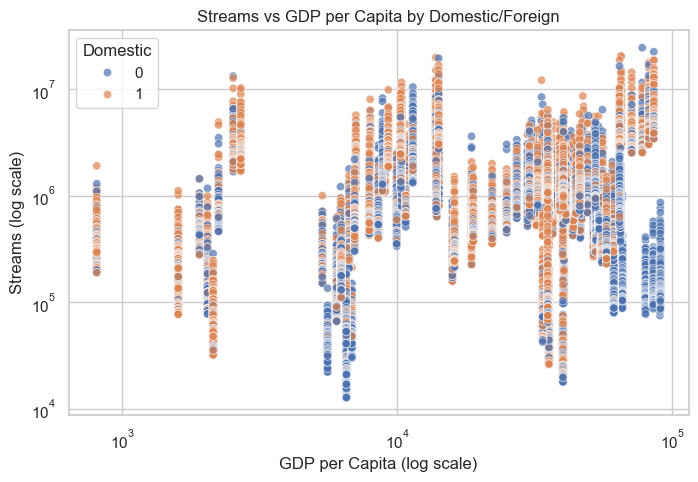

In [58]:
# scatter: GDP per capita vs Streams
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='NY.GDP.PCAP.CD', y='streams', hue='domestic', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("GDP per Capita (log scale)")
plt.ylabel("Streams (log scale)")
plt.title("Streams vs GDP per Capita by Domestic/Foreign")
plt.legend(title="Domestic")
plt.show()

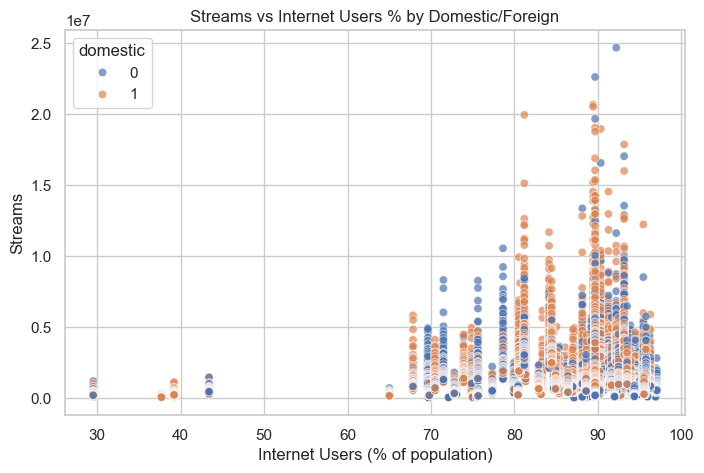

In [59]:
# scatter: internet users % vs streams
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='IT.NET.USER.ZS', y='streams', hue='domestic', alpha=0.7)
plt.xlabel("Internet Users (% of population)")
plt.ylabel("Streams")
plt.title("Streams vs Internet Users % by Domestic/Foreign")
plt.show()

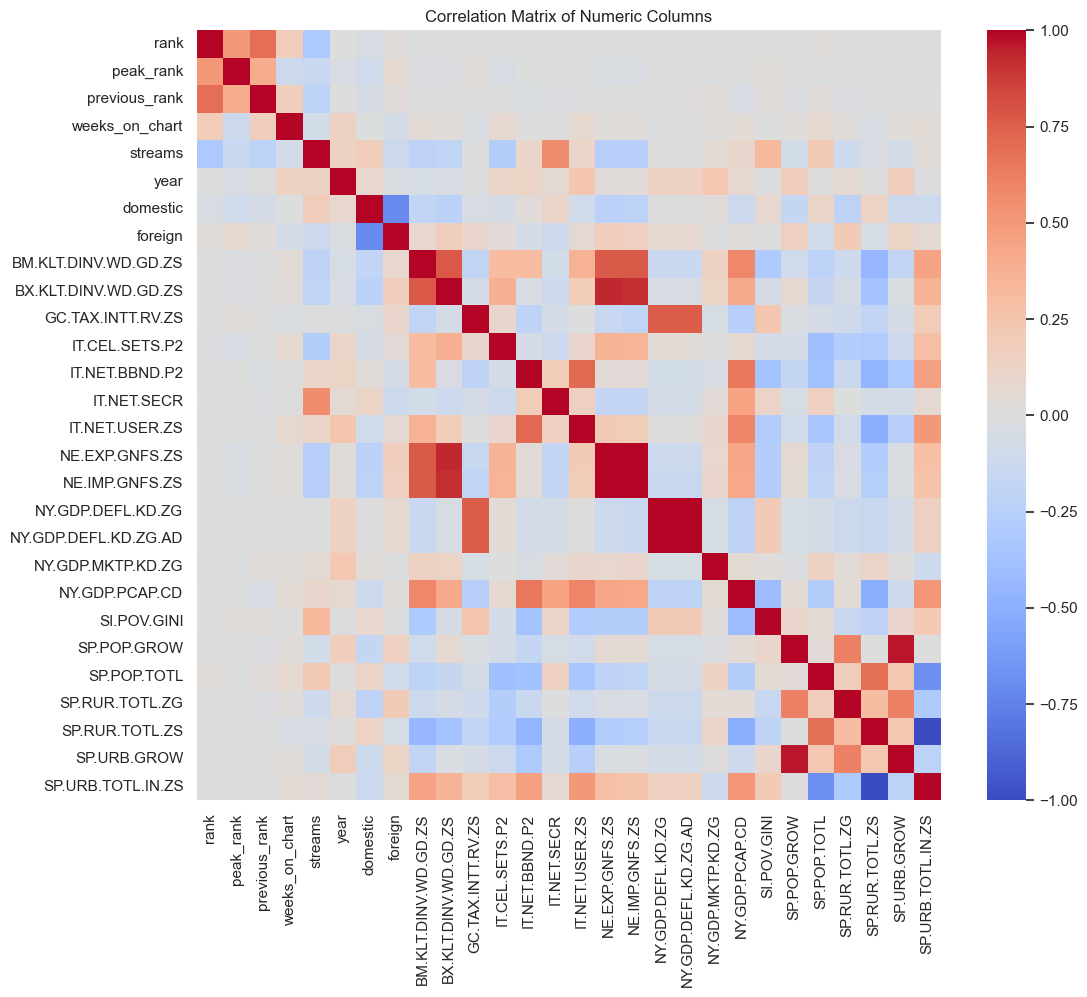

In [60]:
# correlation heatmap of numeric wb indicators
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Matrix of Numeric Columns")
plt.show()

In [61]:
# avg gdp per capita by country cluster over years
avg_gdp = df.groupby(['year','cluster'])['NY.GDP.PCAP.CD'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=avg_gdp, x='year', y='NY.GDP.PCAP.CD', hue='cluster', marker='o')
plt.title("GDP per Capita Trends by Economic Cluster")
plt.ylabel("Average GDP per Capita")
plt.show()

KeyError: 'cluster'

# ML / Statistical Analysis

Load Data and Preprocessing

In [ ]:
# Ensure numeric columns are float
df = pd.read_csv(file_path)
numeric_cols = [
    'BM.KLT.DINV.WD.GD.ZS','BX.KLT.DINV.WD.GD.ZS','IT.CEL.SETS.P2','IT.NET.BBND.P2',
    'IT.NET.SECR','IT.NET.USER.ZS','NE.EXP.GNFS.ZS','NE.IMP.GNFS.ZS','NY.GDP.DEFL.KD.ZG',
    'NY.GDP.DEFL.KD.ZG.AD','NY.GDP.MKTP.KD.G','NY.GDP.PCAP.CD','SP.POP.GROW','SP.POP.TOTL',
    'SP.RUR.TOTL.ZG','SP.RUR.TOTL.ZS','SP.URB.GROW','SP.URB.TOTL.IN.ZS',
    'GC.TAX.INTT.RV.WD.GD.ZS', 'SI.POV.GINI'
]
# Convert to numeric (force errors to NaN)
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Log transform streams to reduce skew
df['log_streams'] = np.log1p(df['streams'])
df_ml = df.copy()

# Display first few rows
df.head(5)

,rank,artist_names,track_name,source,peak_rank,previous_rank,weeks_on_chart,streams,country_code,country_name,...,NY.GDP.MKTP.KD.ZG,NY.GDP.PCAP.CD,SI.POV.GINI,SP.POP.GROW,SP.POP.TOTL,SP.RUR.TOTL.ZG,SP.RUR.TOTL.ZS,SP.URB.GROW,SP.URB.TOTL.IN.ZS,log_streams
0,1,"Pedro Capó, Farruko",Calma - Remix,Sony Music Latin,1,2,10,2506857,AR,Argentina,...,-2.000861,9955.974787,43.3,0.710901,44973465.0,-0.788598,8.009,0.842522,91.991,14.734541
1,2,Paulo Londra,Adan y Eva,WEA Latina,1,1,10,2451964,AR,Argentina,...,-2.000861,9955.974787,43.3,0.710901,44973465.0,-0.788598,8.009,0.842522,91.991,14.712400
2,3,DJ Alex,Leña para el Carbón,DJ Alex,3,3,5,1709216,AR,Argentina,...,-2.000861,9955.974787,43.3,0.710901,44973465.0,-0.788598,8.009,0.842522,91.991,14.351546
3,4,"Bad Bunny, Drake",MIA,Rimas Entertainment LLC,2,5,13,1427528,AR,Argentina,...,-2.000861,9955.974787,43.3,0.710901,44973465.0,-0.788598,8.009,0.842522,91.991,14.171456
4,5,"Duki, DrefQuila",Sin Culpa (feat.DrefQuila),SSJ Records / DALE PLAY Records,5,6,5,1389999,AR,Argentina,...,-2.000861,9955.974787,43.3,0.710901,44973465.0,-0.788598,8.009,0.842522,91.991,14.144814


In [ ]:
# linear regression - streams vs. economic indicators
import statsmodels.api as sm

# Select features and target
features = [
    'NY.GDP.PCAP.CD','SP.URB.TOTL.IN.ZS','IT.NET.USER.ZS','domestic'
]
df_model = df_ml.dropna(subset=features + ['log_streams'])

X = df_model[features]
y = df_model['log_streams']

# Add constant for intercept
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_streams   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     774.0
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:43:22   Log-Likelihood:                -42588.
No. Observations:               28000   AIC:                         8.519e+04
Df Residuals:                   27995   BIC:                         8.523e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.8798      0.06

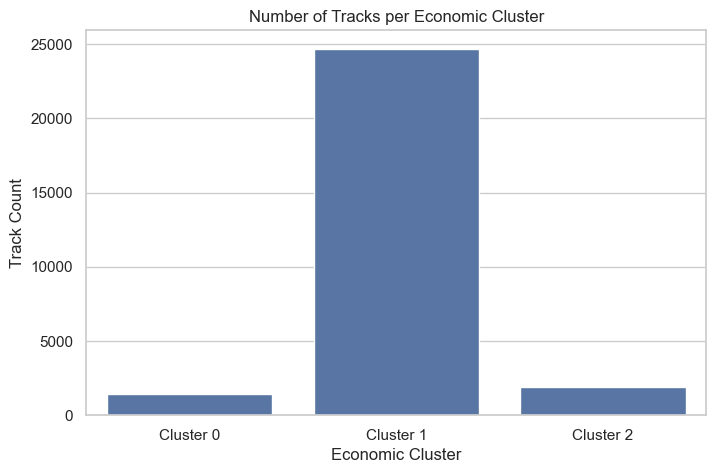

In [37]:
# Cell: K-Means Clustering for Economic Clusters
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('../../data/processed/spotify-wb-cleaned.csv')

# Select only numeric economic indicators for clustering
econ_cols = [
    'BM.KLT.DINV.WD.GD.ZS','BX.KLT.DINV.WD.GD.ZS','IT.CEL.SETS.P2','IT.NET.BBND.P2',
    'IT.NET.SECR','IT.NET.USER.ZS','NE.EXP.GNFS.ZS','NE.IMP.GNFS.ZS',
    'NY.GDP.DEFL.KD.ZG','NY.GDP.DEFL.KD.ZG.AD','NY.GDP.MKTP.KD.ZG','NY.GDP.PCAP.CD',
    'SP.POP.GROW','SP.POP.TOTL','SP.RUR.TOTL.ZG','SP.RUR.TOTL.ZS',
    'SP.URB.GROW','SP.URB.TOTL.IN.ZS'
]

# Drop rows with missing values in clustering features
df_cluster = df.dropna(subset=econ_cols).copy()

# Standardize numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[econ_cols])

# Decide on number of clusters: let's use 3 for low/upper-mid/high income
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_cluster['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Map cluster numbers to meaningful labels if desired (optional)
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}
df_cluster['kmeans_cluster_label'] = df_cluster['kmeans_cluster'].map(cluster_labels)

# Plot cluster counts
plt.figure(figsize=(8,5))
sns.countplot(x='kmeans_cluster_label', data=df_cluster, order=sorted(cluster_labels.values()))
plt.title("Number of Tracks per Economic Cluster")
plt.ylabel("Track Count")
plt.xlabel("Economic Cluster")
plt.show()

df_cluster.to_csv('../../data/processed/spotify-wb-clustered.csv', index=False)

In [33]:
# logistic Regression classification - predict domestic vs. foreign tracks
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Features: economic indicators
features_class = ['NY.GDP.PCAP.CD','SP.URB.TOTL.IN.ZS','IT.NET.USER.ZS','SP.POP.TOTL']
df_class = df_ml.dropna(subset=features_class + ['domestic'])

X_class = df_class[features_class]
y_class = df_class['domestic']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Fit logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predictions and metrics
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.76      0.62      2876
           1       0.53      0.29      0.37      2724

    accuracy                           0.53      5600
   macro avg       0.53      0.52      0.50      5600
weighted avg       0.53      0.53      0.50      5600



In [32]:
# outlier detection with z-score - unexpected streaming hits
from scipy.stats import zscore
df_outlier = df_ml.copy()

# Compute Z-score for log_streams by country-year
df_outlier['streams_z'] = df_outlier.groupby(['country_code','year'])['log_streams'].transform(zscore)

# Identify top outliers
outliers = df_outlier[df_outlier['streams_z'] > 3]  # >3 std deviations
outliers[['track_name','artist_names','country_name','year','streams','streams_z']]

,track_name,artist_names,country_name,year,streams,streams_z
250,bad guy,Billie Eilish,Australia,2019,2670614,3.545015
300,Señorita,"Shawn Mendes, Camila Cabello",Australia,2019,2240890,3.044481
350,Dance Monkey,Tones And I,Australia,2019,2300017,3.118786
650,Old Town Road (feat. Billy Ray Cyrus) - Remix,"Lil Nas X, Billy Ray Cyrus",Canada,2019,2330571,3.145630
700,Señorita,"Shawn Mendes, Camila Cabello",Canada,2019,2531730,3.364990
...,...,...,...,...,...,...
27756,Wi$h Li$t,Taylor Swift,United States,2025,28917563,3.190263
27757,Eldest Daughter,Taylor Swift,United States,2025,28291338,3.146333
27758,CANCELLED!,Taylor Swift,United States,2025,28183779,3.138689
27759,The Life of a Showgirl (feat. Sabrina Carpenter),"Taylor Swift, Sabrina Carpenter",United States,2025,28006950,3.126060
